## Race Evaluations

In [43]:
#Import modules
from deepracer.tracks import TrackIO, Track
from deepracer.tracks.track_utils import track_meta

from deepracer.logs import \
    AnalysisUtils as au, \
    SimulationLogsIO as slio, \
    EvaluationUtils as eu, \
    PlottingUtils as pu, \
    DeepRacerLog, \
    S3FileHandler, FSFileHandler, \
    LogType

import os
import yaml
from pprint import pprint

# Ignore deprecation warnings we have no power over
import warnings
warnings.filterwarnings('ignore')

#path to race models /home/uncle/deepracer-for-cloud/

In [44]:
#Loading all data for the race
#Looking at all models in model_to_race folder
os.chdir("\\\\wsl$\\Ubuntu\\home\\spenc\\deepracer-for-cloud")
file_name = 'models_to_race.txt'
with open(file_name, 'r') as file:
    race_models = file.readlines()
race_models = [line.strip() for line in race_models]
print('Racer model names:')
for model in race_models:
    print(race_models)

# Setting path to minio bucket
#PREFIX= race_models[racer]      # Name of the model, without trailing '/'
BUCKET='bucket'    # Bucket name is default 'bucket' when training locally
PROFILE='minio'                # The credentials profile in .aws - 'minio' for local training
S3_ENDPOINT_URL='http://172.22.79.106:9000'

# Load all eval data into dict key = model name, value = model dataframe
race_stats = {}
for i, racer in enumerate(race_models):
    PREFIX= race_models[i]
    fh = S3FileHandler(bucket=BUCKET, prefix=PREFIX, profile=PROFILE, s3_endpoint_url=S3_ENDPOINT_URL)
    log = DeepRacerLog(filehandler=fh)
    log.load_evaluation_trace()
    df = log.dataframe()
    sorted = df.sort_values(by='stream', ascending=False)
    sorted = sorted.sort_values(by=['episode','steps'])
    newest = sorted[sorted['stream'] == sorted['stream'].max()]
    race_stats[racer] = newest

Racer model names:
['2026_02_18_3']


## Track Name

In [45]:
# Pull track name from evaluation_params.yaml
eval_file = fh.get_file('/'+PREFIX+'/evaluation_params.yaml')
eval_params = yaml.safe_load(eval_file)
track_name = eval_params['WORLD_NAME']
direction = eval_params['REVERSE_DIR']
# Path to Analysis folder
analysis_path = "C:\\Users\\spenc\\OneDrive\\Documents\\deepracer-analysis"
tu = TrackIO(base_path=(analysis_path + '/tracks'))
track: Track = tu.load_track(track_name)

print('----'*25)
print(track_name)
if direction == 'True':
    print('Reverse Direction')
else:
    print('Standard Direction')

#pu.plot_trackpoints(track)
#pu.plot_trackpoints(track)

Loaded 112 waypoints
----------------------------------------------------------------------------------------------------
reInvent2019_wide
Reverse Direction


## Lap Times

In [46]:
#load lap times
#laps_run = int(eval_params['NUMBER_OF_TRIALS'])
for racer in race_models:
    simulation_agg = au.simulation_agg(race_stats[racer], 'stream', is_eval=True)
    complete_ones = simulation_agg[simulation_agg['progress']==100]
    desired_data = ['stream','time_if_complete','off_track']
    print(racer)
    pprint(complete_ones[desired_data])
    print('----'*25)

2026_02_18_3
           stream  time_if_complete  off_track
0  20260227084846            19.894          2
1  20260227084846            13.462          1
2  20260227084846            14.065          1
----------------------------------------------------------------------------------------------------


2026_02_18_3


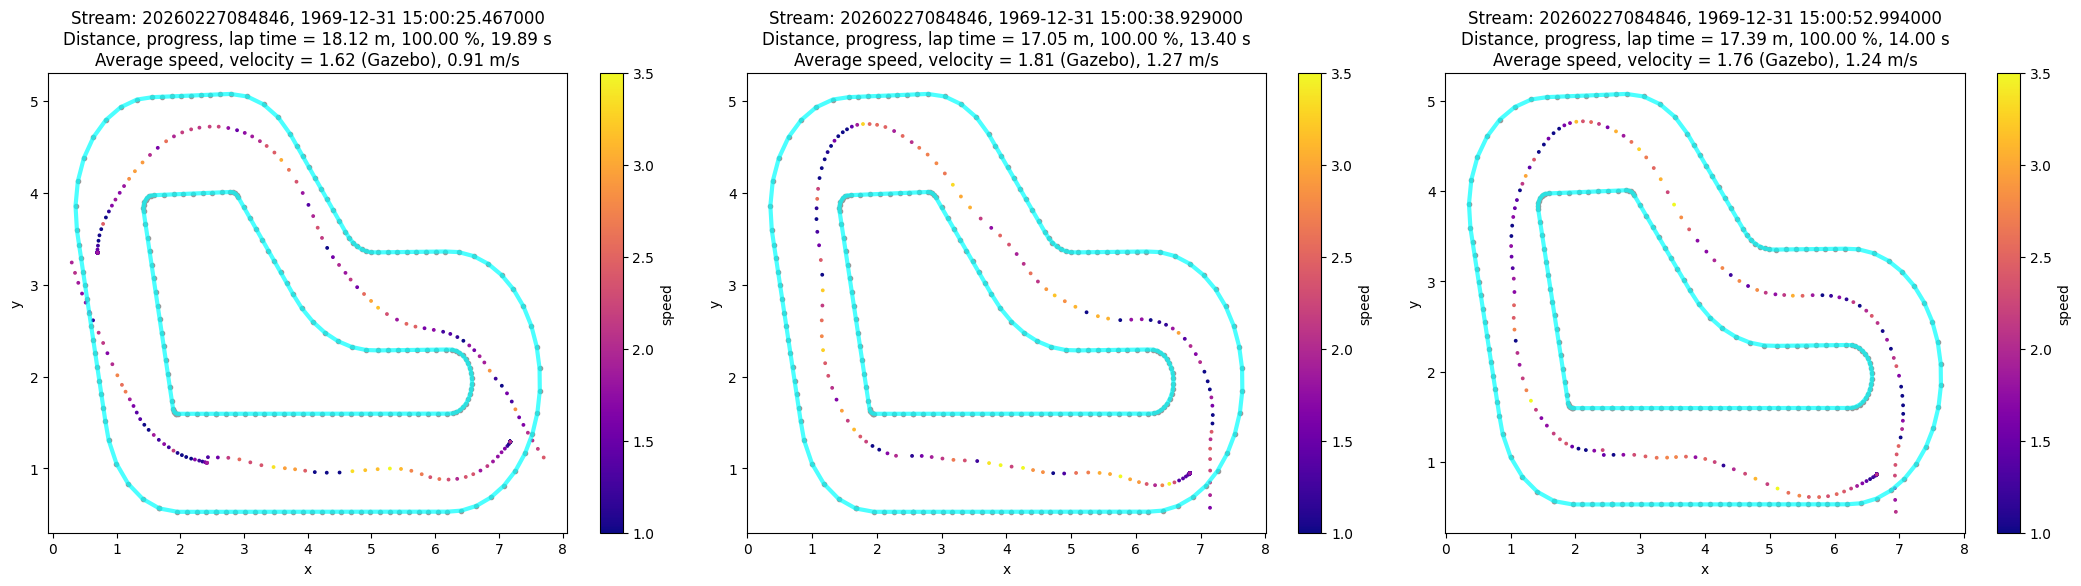

<Figure size 640x480 with 0 Axes>

In [47]:
#load maps of race paths
for racer in race_models:
    print(racer)
    top_races = pu.plot_evaluations(race_stats[racer], track=track)